---
---

# **Employee Performance Level: Exploration and Analysis**  
*Authored by Sean Kafka Adhyaksa*

---
---

This project examines employee performance levels across 311 employee records in order to understand which employee conditions, work patterns, and organizational signals are most closely associated with stronger or weaker performance outcomes.

The dataset was created by Dr. Richard Huebner and published on Kaggle. It combines employee profile, employment history, compensation, review, satisfaction, and attendance-related variables, making it suitable for both exploratory analysis and later classification modeling.

**Key Findings**  
1. `PerformanceScore` is heavily concentrated in **Fully Meets** with **243 of 311 employees**, while **Needs Improvement** and **PIP** account for much smaller groups. This suggests that performance issues exist, but they are concentrated rather than widespread, and the later modeling stage will need to handle class imbalance carefully.  

2. The clearest numeric separation comes from **engagement, satisfaction, tardiness, salary, and special-project exposure**, not from age at hire or tenure. Lower-performing employees tend to be less engaged, less satisfied, more frequently late, and less involved in special projects.  

3. Personal profile variables such as **gender** and **marital status** add only limited separation. In contrast, **employment status, department context, and day-to-day work signals** tell a more useful story, especially when weaker performance appears together with termination-for-cause patterns.  

4. Sensitive demographic variables such as **race** and **HispanicLatino** are explored only to understand dataset composition. They should not be treated as practical levers for employee evaluation, which keeps the analysis aligned with both business ethics and sound HR decision-making.

**Recommendations**  
1. Build an early warning view around **engagement, satisfaction, lateness, and work exposure**, because these signals separate performance groups more clearly than static profile attributes.  

2. Investigate weaker performance through **work context**, especially across departments, employment outcomes, and everyday work behavior, rather than relying on personal identity variables.  

3. Treat sensitive demographic fields with care and avoid turning them into direct decision criteria, even when they are available in the dataset.  

4. Prepare the modeling stage with careful **feature selection, class imbalance handling, and cautious interpretation**, so the final predictive model remains useful and fair.

**Dashboard and Model Deployment**  
The deployed application can be accessed through [**Hugging Face**](https://huggingface.co/spaces/seankafka/Employee-Performance-Prediction).

---
# **Introduction**
---

## **Case Scenario**

Human Resource division conducts routine performance reviews to support decisions related to training, promotion, and periodic evaluation. However, manual assessment can still be time-consuming, difficult to standardize, and vulnerable to subjective judgment across reviewers or departments.

Because of that, HR needs a more structured analytical approach to better understand the patterns associated with stronger and weaker employee performance. By using data, the evaluation process can be supported with clearer evidence on which employee and workplace factors tend to appear alongside different performance outcomes.

The goal is not to replace human judgment, since performance still needs to be interpreted within a broader organizational context. Instead, this analysis is intended to support HR with a more consistent, transparent, and evidence-based foundation for employee development and evaluation decisions.

## **Problem Statement**

The HR Manager needs a data-driven way to understand which factors are most closely associated with employee performance and which employee conditions may signal higher risk of weaker performance.

To address that business need, the analysis is organized around the following questions:

1. How is `PerformanceScore` distributed, and does the dataset show any imbalance that could affect later modeling?

2. Which numeric signals, such as salary, engagement, satisfaction, lateness, absences, and project exposure, separate performance groups most clearly?

3. Do derived time-based features such as age at hire and tenure add useful explanatory value?

4. Which categorical patterns appear across personal profile, employment status, department context, and manager structure?

5. Which findings are useful for the next modeling stage, and which variables should be interpreted more cautiously from a business and ethical perspective?

## **Project Goals**

1. Build a predictive framework for employee `PerformanceScore` using the available HR dataset.

2. Identify which variables are most informative for explaining performance differences across employees.

3. Compare several machine learning algorithms in a separate modeling stage to find the most reliable classification approach.

4. Translate the findings into practical HR recommendations, especially for early warning monitoring, training prioritization, and more objective performance support.

This project is designed to build a model that can help predict employee `PerformanceScore` from internal company data. Even so, the model is not intended to replace HR evaluation. Its role is to function as a support tool that adds structure, consistency, and an additional layer of evidence in the decision-making process.

This notebook focuses on the end-to-end analytical foundation: understanding the dataset, cleaning the data, exploring patterns, and identifying which variables deserve attention before modeling. The separate modeling notebook then continues that work into feature engineering, algorithm comparison, and predictive evaluation.

---
# **Dataset Overview**
---

- **Dataset**: `HRDataset_v14`

- **Number of Rows**: 311

- **Number of Original Columns**: 36

- **Author**: Dr. Richard Huebner

- **Source**: [Kaggle](https://www.kaggle.com/datasets/rhuebner/human-resources-data-set)

**Data Dictionary**  
![alt text](dataset\dataset-description.png)  
[Source](https://rpubs.com/rhuebner/hrd_cb_v14)

---
# **Importing Libraries**
---

In [1]:
# data handling
import pandas as pd
import numpy as np

# statistical tools
from scipy.stats import chi2_contingency

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# misc
import warnings
warnings.filterwarnings("ignore")

---
# **Data Preparation**
---

## **Data Loading**

In [2]:
# initial loading
df = pd.read_csv('dataset\HRDataset_v14.csv')

In [3]:
# load first 10 and last 10 data
display(pd.concat([df.head(10), df.tail(10)]))

# display rows and columns
print(f'dataset rows and columns: {df.shape}')

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11.0,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15
6,"Andreola, Colby",10194,0,0,0,1,4,3,0,95660,...,Alex Sweetwater,10.0,LinkedIn,Fully Meets,3.04,3,4,1/2/2019,0,19
7,"Athwal, Sam",10062,0,4,1,1,5,3,0,59365,...,Ketsia Liebig,19.0,Employee Referral,Fully Meets,5.00,4,0,2/25/2019,0,19
8,"Bachiochi, Linda",10114,0,0,0,3,5,3,1,47837,...,Brannon Miller,12.0,Diversity Job Fair,Fully Meets,4.46,3,0,1/25/2019,0,4
9,"Bacong, Alejandro",10250,0,2,1,1,3,3,0,50178,...,Peter Monroe,7.0,Indeed,Fully Meets,5.00,5,6,2/18/2019,0,16


dataset rows and columns: (311, 36)


The dataset contains **311 rows and 36 columns** at the initial loading stage. It covers a broad mix of employee information, including profile, hiring history, compensation, satisfaction, attendance, manager assignment, and performance review variables.

That coverage is useful because employee performance rarely comes from a single factor. At the same time, the raw structure also includes duplicated identifiers, encoded companion columns, and several date fields that still need preparation before the analysis can move forward safely.

---

## **Dropping Redundant Columns**

Referring back to the data dictionary, several columns appear in paired form: one readable business label and one encoded identifier that carries the same meaning. For exploratory analysis, the readable version is more useful because it is easier to interpret and discuss.

The following groups contain overlapping information:

- `Employee_Name` and `EmpID` function as employee identifiers, so they do not add analytical value for performance exploration.

- `MaritalDesc`, `MarriedID`, and `MaritalStatusID` describe marital condition at different levels of detail.

- `Sex` and `GenderID` represent the same employee attribute in different formats.

- `EmploymentStatus` and `EmpStatusID`, `Department` and `DeptID`, `PerformanceScore` and `PerfScoreID`, `Position` and `PositionID`, `ManagerName` and `ManagerID`, and `RecruitmentSource` and `FromDiversityJobFairID` follow the same pattern.

For this notebook, the more interpretable business-facing columns are retained, while redundant encoded columns are dropped. Address-related fields such as `State` and `Zip` are also removed because they behave more like location identifiers than meaningful performance drivers in this project.

In [4]:
# drop redundant columns
df.drop(columns=[
    'Employee_Name', 'EmpID', 'MaritalStatusID',
     'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID',
     'FromDiversityJobFairID', 'PositionID', 'ManagerID'
     ],inplace=True)

# drop address columns
address = ['State', 'Zip']
df.drop(columns=address, inplace=True)

---

## **Reformatting Columns**

Two binary columns, `MarriedID` and `Termd`, still use 0 and 1. Reformatting them into `Yes` and `No` makes the data easier to read and keeps the notation consistent with columns such as `HispanicLatino`.

At the same time, renaming them to `IsMarried` and `IsTerminated` makes their meaning clearer, especially once the notebook begins comparing employee groups.

In [5]:
# Reformatting binary columns
df['IsMarried'] = df['MarriedID'].map({0: 'No', 1: 'Yes'})
df['IsTerminated'] = df['Termd'].map({0: 'No', 1: 'Yes'})

# drop original binary columns
df.drop(columns=['MarriedID', 'Termd'], inplace=True)

# Reformatting 'HispanicLatino' column
df['HispanicLatino'] = df['HispanicLatino'].str.strip().str.title() # 'no' becomes 'No'

---

## **Checking Data Duplicates**

In [6]:
# duplicated rows
df.duplicated().sum()

0

No duplicated rows were found, which means the dataset represents 311 distinct employee records.

---

## **Checking Data Type**

In [7]:
# display dtypes in DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Salary                      311 non-null    int64  
 1   Position                    311 non-null    object 
 2   DOB                         311 non-null    object 
 3   Sex                         311 non-null    object 
 4   MaritalDesc                 311 non-null    object 
 5   CitizenDesc                 311 non-null    object 
 6   HispanicLatino              311 non-null    object 
 7   RaceDesc                    311 non-null    object 
 8   DateofHire                  311 non-null    object 
 9   DateofTermination           104 non-null    object 
 10  TermReason                  311 non-null    object 
 11  EmploymentStatus            311 non-null    object 
 12  Department                  311 non-null    object 
 13  ManagerName                 311 non

After the initial column reduction, the dataset contains **24 columns**. Most of them already follow a sensible structure: compensation, review scores, lateness, project count, and absences are numeric, while employee profile and employment descriptors remain categorical.

The main issue is that the four date fields are still stored as `object`, even though they represent calendar information. Before any time-based exploration, `DOB`, `DateofHire`, `DateofTermination`, and `LastPerformanceReview_Date` need to be converted into proper datetime format.

A small additional check is also necessary for `DOB`, because two-digit year parsing can sometimes push older birth years into the wrong century. Correcting that issue early helps keep later feature engineering more trustworthy.

In [8]:
# Reformatting Datetime columns
date_cols = ['DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

#-------------# DEBUG for 'DOB' %y #------------#
# Pandas 'dateutil' default settings are:       #
#   00-68 → 2000-2068,                          #
#   69–99 → 1969–1999,                          #
#-----------------------------------------------#
# Example: we want year:64 to be 1964, NOT 2064 #
#-----------------------------------------------#
current_year = df['DateofHire'].max().year

df.loc[df['DOB'].dt.year > current_year, 'DOB'] = (
    df.loc[df['DOB'].dt.year > current_year, 'DOB'] - pd.DateOffset(years=100)
    )

---

## **Checking Missing Values**

In [9]:
# check missings in DataFrame
df_mv = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'non_null_values': df.notnull().sum()
})

# only query columns with missing values
df_mv[df_mv['missing_values'] > 0]

,missing_values,non_null_values
DateofTermination,207,104


In [10]:
# sanity check: terminated employees
df['DateofTermination'].notnull().sum() == len(df[df['IsTerminated'] == 'Yes'])

True

In [11]:
# sanity check: active employees
df['DateofTermination'].isnull().sum() == len(df[df['IsTerminated'] == 'No'])

True

`DateofTermination` is missing for **207 employees**, but this pattern is expected because only terminated employees have an exit date recorded. The sanity checks confirm that the missingness aligns exactly with `IsTerminated`, so this is not treated as a data quality problem.

The rest of the dataset is complete, which means the analysis can continue without broader missing-value handling.

---

## **Checking Whitespace**

Whitespace issues can quietly create messy categories, especially in object columns. A value such as `" Sales"` and `"Sales"` may look the same to the eye, but they behave as different categories during grouping and modelling.

Because of that, all object columns are checked for leading and trailing whitespace before moving further into the analysis.

In [12]:
print('Checking whitespace:\n')

# checking lead/trail whitespace char in columns with Dtype: 'object'
for col in df.select_dtypes(include='object').columns:
    any_ws = df[col].astype(str).str.contains(r'^\s|\s$', regex=True).any()

    print(f'Found whitespace in {col}') if any_ws else print(f'No lead/trail whitespace in {col}') 

Checking whitespace:

Found whitespace in Position
Found whitespace in Sex
No lead/trail whitespace in MaritalDesc
No lead/trail whitespace in CitizenDesc
No lead/trail whitespace in HispanicLatino
No lead/trail whitespace in RaceDesc
No lead/trail whitespace in TermReason
No lead/trail whitespace in EmploymentStatus
Found whitespace in Department
No lead/trail whitespace in ManagerName
No lead/trail whitespace in RecruitmentSource
No lead/trail whitespace in PerformanceScore
No lead/trail whitespace in IsMarried
No lead/trail whitespace in IsTerminated


Whitespace was found in three categorical columns: `Position`, `Sex`, and `Department`.

This is a small issue, but it matters because category labels need to be fully consistent before any grouping, crosstab, or modeling step. After trimming those spaces, the categorical structure becomes safer to interpret.

In [13]:
# remove whitespace
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

---

## **Checking Zero Variance Columns**

A zero-variance column contains the same value in every row. Columns like this do not help separate one employee from another, so they only increase dataset size without adding real analytical value.

Checking this early helps confirm whether any non-informative fields still remain after the first round of column reduction.

In [14]:
# query singular value columns
unique = df.nunique()
unique[unique == 1]

Series([], dtype: int64)

---

## **Checking High Cardinality Identifier Columns**

High-cardinality columns need a different kind of caution. A field can look informative simply because it contains many unique values, but that does not automatically make it useful. In HR data, this often happens with identifier-like columns.

At this stage, the goal is to make sure the remaining variables describe employee conditions, not just individual record labels.

In [15]:
# columns with unique values same as length of rows
df.nunique()[df.nunique() == len(df)]

Series([], dtype: int64)

No remaining columns have a number of unique values equal to the number of rows.

This is a good sign that the earlier removal of employee identifiers and duplicate ID columns was effective. The remaining dataset is now much closer to an analysis-ready structure.

---

## **Checking Outlier Data**

Investigating outliers is not used here as a reason to remove rows automatically. The main purpose is to understand whether any values look unreasonable or whether they simply reflect natural variation in employee profiles.

The detection method is adjusted to the shape of each distribution. Variables closer to normal are checked with mean ± 3 standard deviations, while more skewed variables are checked with a more flexible IQR-based boundary.

In [16]:
def skewness_outliers(dataframe):
    '''
    This function takes in a DataFrame and returns a new DataFrame
    with skewness and outlier information for each numerical column,
    which includes:
        skewness, distribution type, upper and lower boundaries,
        outlier count, and outlier percentage.
    '''
    num_cols = list(dataframe.select_dtypes(np.number).columns)

    list_item = []

    for col in num_cols:
        # detect skewness and distribution type
        skew_val = round(dataframe[col].skew(), 2)
        if -0.5 <= skew_val <= 0.5:
            dist_type = 'normal'
        elif -1 <= skew_val <= -0.5 or 0.5 <= skew_val <= 1:
            dist_type = 'moderately skewed'
        else:
            dist_type = 'highly skewed'

        # upper and lower boundaries for normal and skewed data
        if dist_type == 'normal':
            lower_boundary = (dataframe[col].mean() - 3 * dataframe[col].std()).round(2)
            upper_boundary = (dataframe[col].mean() + 3 * dataframe[col].std()).round(2)

        else:
            IQR = dataframe[col].quantile(0.75) - dataframe[col].quantile(0.25)
            lower_boundary = (dataframe[col].quantile(0.25) - (IQR * 3)).round(2)
            upper_boundary = (dataframe[col].quantile(0.75) + (IQR * 3)).round(2)
        
        # outlier count and percentage
        outlier_count = len(dataframe[(dataframe[col] > upper_boundary) | (dataframe[col] < lower_boundary)])
        outlier_pct = round((outlier_count / len(dataframe)) * 100, 2)

        # adding the findings to list_item empty list
        list_item.append([
            col,
            skew_val, dist_type,
            lower_boundary, upper_boundary,
            outlier_count, outlier_pct
        ])

    # create DataFrame
    skewness_outliers = pd.DataFrame(
        list_item,
        columns=[
            'column_label',
            'skewness', 'distribution',
            'lower_boundary', 'upper_boundary',
            'outlier_count', 'outlier%'
        ])

    # returns new DataFrame    
    return skewness_outliers

In [17]:
# show descriptive stats
skewness_outliers(df)

,column_label,skewness,distribution,lower_boundary,upper_boundary,outlier_count,outlier%
0,Salary,3.31,highly skewed,5898.00,121639.50,10,3.22
1,EngagementSurvey,-1.12,highly skewed,0.66,7.73,0,0.00
2,EmpSatisfaction,-0.22,normal,1.16,6.62,2,0.64
3,SpecialProjectsCount,1.54,highly skewed,0.00,0.00,70,22.51
4,DaysLateLast30,3.14,highly skewed,0.00,0.00,33,10.61
5,Absences,0.03,normal,-7.32,27.80,0,0.00


`Salary` is the clearest right-skewed variable, which is reasonable in an employee dataset because most employees sit in regular pay bands while a much smaller group occupies higher-paid leadership or specialist roles. `SpecialProjectsCount` and `DaysLateLast30` are also heavily concentrated near zero, so their extreme values reflect uncommon behavior rather than obvious input mistakes.

Across the numeric features, the detected outliers still look plausible in business context. For that reason, no rows are removed at this stage. Keeping them is important because unusually high salary, repeated lateness, or exceptional project exposure may be part of the real performance story rather than noise.

---

## **Summary: Data Cleaning Report**

Overall, the dataset is in good condition to move into exploration without aggressive correction.

A few important points stand out from the preparation stage:

- The initial dataset contains **311 rows and 36 columns**, and after removing redundant fields it becomes a cleaner **24-column** structure.
- No duplicated rows remain.
- Missing values only appear in `DateofTermination`, and that pattern is expected because active employees do not have an exit date.
- Whitespace issues in `Position`, `Sex`, and `Department` were fixed.
- Redundant identifiers and duplicate encoded columns were removed.
- Date columns were converted into proper datetime format, including a correction step for ambiguous birth-year parsing.
- Extreme values still look plausible in business context, so no rows were dropped.

With the structure cleaned and the main data quality checks completed, the next step is to examine employee performance itself and see which parts of the dataset actually help separate the performance groups.

---
# **Exploratory Data Analysis**
---

## **Target Variable: `PerformanceScore`**

One of the 24 cleaned columns is selected as the target for the later modeling stage: `PerformanceScore`.

Before building any model, it is important to understand how this target is distributed. That step matters because the shape of the target variable affects not only interpretation, but also evaluation strategy and modeling difficulty.

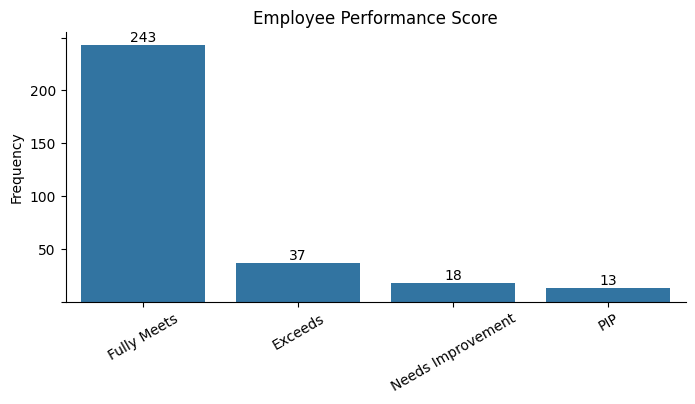

In [18]:
plt.figure(figsize=(8, 3.5))

# visualize
ax = sns.countplot(
    data=df,
    x='PerformanceScore',
    order=df['PerformanceScore'].value_counts().index
)
plt.title('Employee Performance Score')
plt.xlabel('')
plt.ylabel('Frequency')
plt.xticks(rotation=30)


ax.bar_label(ax.containers[0])
yticks = ax.get_yticks()
ax.set_yticklabels([
    int(tick) if int(tick) in [50, 100, 150, 200] else '' for tick in yticks
])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Unlike many performance datasets that store performance as a numeric score, this dataset records `PerformanceScore` as a categorical outcome with four ordered levels:

- `PIP`
- `Needs Improvement`
- `Fully Meets`
- `Exceeds`

The distribution is highly uneven: **243 employees** are in `Fully Meets`, followed by **37** in `Exceeds`, **18** in `Needs Improvement`, and **13** in `PIP`.

This makes the later modeling task a **multi-class classification** problem, not a regression problem. It also immediately shows a class imbalance issue, because the majority of employees cluster in `Fully Meets` while the lower-performance groups are much smaller.

---

## **DateTime Features Exploration**

In [19]:
# checking date columns dtypes
df[date_cols].dtypes

DOB                           datetime64[ns]
DateofHire                    datetime64[ns]
DateofTermination             datetime64[ns]
LastPerformanceReview_Date    datetime64[ns]
dtype: object

There are four datetime-related fields in the dataset: `DOB`, `DateofHire`, `DateofTermination`, and `LastPerformanceReview_Date`. Even after conversion, raw calendar values are not very informative on their own, and some of them can introduce temporal leakage if handled carelessly.

Because of that, the goal here is not to use every date column directly. Instead, the notebook extracts the most interpretable time-based signals that can still be discussed safely in relation to employee performance.

In [20]:
# descriptive stats for date columns
df[date_cols].describe()

,DOB,DateofHire,DateofTermination,LastPerformanceReview_Date
count,311,311,104,311
mean,1979-02-06 09:48:02.315112544,2013-02-03 22:50:32.797427712,2015-06-14 11:46:09.230769152,2017-09-10 21:17:56.527331072
min,1951-01-02 00:00:00,2006-01-09 00:00:00,2010-08-30 00:00:00,2010-07-14 00:00:00
25%,1973-12-03 00:00:00,2011-07-11 00:00:00,2014-01-10 12:00:00,2016-03-19 12:00:00
50%,1980-09-30 00:00:00,2013-02-18 00:00:00,2015-09-22 00:00:00,2019-01-16 00:00:00
75%,1986-05-29 12:00:00,2014-09-23 12:00:00,2016-09-08 06:00:00,2019-02-04 00:00:00
max,1992-08-17 00:00:00,2018-07-09 00:00:00,2018-11-10 00:00:00,2019-02-28 00:00:00


The descriptive summary of the raw date columns confirms that the values are now stored correctly, but it is still difficult to interpret them directly. Dates are easier to use once they are translated into business-facing measures such as age at hire or years of experience (tenure).

For that reason, the analysis focuses on `DOB` and `DateofHire`, then turns them into features that are more interpretable and more practical for later exploration.

### **1. Derivating New Feature: `StartWorkAge`**

Date of Birth data can be transformed into a more useful feature by measuring how old each employee was when joining the company. This new feature is named `StartWorkAge`.

Using age at hire is more meaningful here than using age at the latest available date, because it ties the employee profile to the starting point of the employment journey rather than mixing it with later events.

In [21]:
# calc & create `StartWorkAge` feature
df['StartWorkAge'] = ((df['DateofHire'] - df['DOB']).dt.days // 365)

### **2. Derivating New Feature: `Tenure` (with Caution)**

`Tenure` refers to how long an employee has been with the company. This can be derived from `DateofHire`, but the reference point needs to be chosen carefully.

A tempting option would be to use `LastPerformanceReview_Date` as the time anchor, because it is operationally close to performance evaluation. However, that choice could leak future information into the modeling process, especially if the review happened after other employee events had already unfolded.

For conservative measures, the notebook uses the latest observed `DateofHire` as a shared snapshot reference. This means newer employees receive lower tenure values, while employees hired much earlier receive higher ones. It is not a perfect real-world measure, but it keeps the feature interpretable while reducing temporal leakage risk.

In [22]:
# snapshot of working year
reference_date = df['DateofHire'].max()
print(f'reference date: {reference_date}')

# calc & create `Tenure` feature
# if 'DateofHire' is/close to 'reference_date', that means they are new comers
df['Tenure'] = ((reference_date - df['DateofHire']).dt.days // 365)

reference date: 2018-07-09 00:00:00


The shared reference date used for this snapshot is **2018-07-09**, which is the most recent hiring date in the dataset.

With that decision, `Tenure` becomes a relative measure of how long each employee has been in the company compared with the newest hire. That makes it suitable for broad grouping and comparison, even though it should still be interpreted as an approximation rather than an exact live HR metric.

### **DateTime Features vs Target**

In [23]:
df.groupby('PerformanceScore')[['StartWorkAge', 'Tenure']].agg(['mean', 'min', 'median', 'max']).round(0)

StartWorkAge                Tenure               
                          mean min median max   mean min median max
PerformanceScore                                                   
Exceeds                   34.0  22   32.0  54    5.0   1    5.0  12
Fully Meets               34.0  19   32.0  63    5.0   0    5.0  11
Needs Improvement         30.0  20   30.0  48    6.0   2    6.0   7
PIP                       34.0  24   33.0  47    5.0   3    4.0   9

Only the two derived features, `StartWorkAge` and `Tenure`, are explored against `PerformanceScore`, because they are the most interpretable and the least risky from a temporal point of view.

The aggregated table does not show a strong or consistent separation. `Needs Improvement` employees appear slightly younger at hire on average, but the medians across the four performance groups still overlap quite heavily. `Tenure` also remains fairly similar from one class to another, with no clear monotonic pattern.

This suggests that age at hire and relative tenure behave more like employee background descriptors than strong standalone drivers of performance level in this dataset.

In [24]:
# categorize tenure
df['TenureCategory'] = pd.cut(
    df['Tenure'],
    bins=[-1, 2, 5, df['Tenure'].max()],
    labels=['Junior', 'Mid', 'Senior']
)

print('Count of Performance Score by Tenure Category:')
display(df.groupby('TenureCategory')['PerformanceScore'].value_counts().unstack().round(2))

print('\nPercentage of Performance Score by Tenure Category:')
display(pd.crosstab(df['TenureCategory'], df['PerformanceScore'], normalize='index').round(2))


Count of Performance Score by Tenure Category:


PerformanceScore,Exceeds,Fully Meets,Needs Improvement,PIP
TenureCategory,,,,
Junior,3,17,1,0
Mid,18,119,6,8
Senior,16,107,11,5



Percentage of Performance Score by Tenure Category:


PerformanceScore,Exceeds,Fully Meets,Needs Improvement,PIP
TenureCategory,,,,
Junior,0.14,0.81,0.05,0.00
Mid,0.12,0.79,0.04,0.05
Senior,0.12,0.77,0.08,0.04


The tenure grouping tells a similar story. Junior employees are still dominated by `Fully Meets`, and the same is true for the Mid and Senior groups. There is a slight increase in `Needs Improvement` and `PIP` within the Senior category, but the difference is not large enough to claim a clean tenure-based pattern.

It is also worth noting that the Junior group is much smaller than the other two groups, so small count changes can shift its proportions quickly. Overall, tenure may still be useful as a supporting feature, but it does not look like a strong separator on its own.

---

## **Numeric Features Exploration**

The numeric part of the dataset contains the original quantitative variables together with the two newly derived features, `StartWorkAge` and `Tenure`.

Exploring them first helps answer an important question: which measurable employee signals actually move together with stronger or weaker performance, and which ones mostly stay stable across groups?

### **Overall Descriptive Stats**

This stage looks at the overall distribution of each numeric feature before connecting them to the target. That matters because the shape of the data often explains later patterns. A highly skewed variable, for example, should not be interpreted in the same way as a more balanced one.

The summary table provides a compact view of central tendency, spread, and skewness, which makes it easier to read the later comparisons with `PerformanceScore`.

In [25]:
# all numeric columns
num_columns = df.select_dtypes(np.number)

# descriptive stats with skewness
numeric_stats = num_columns.describe().round(2).T
numeric_stats['skewness'] = num_columns.skew().round(2)
display(numeric_stats)

,count,mean,std,min,25%,50%,75%,max,skewness
Salary,311.0,69020.68,25156.64,45046.00,55501.50,62810.00,72036.0,250000.0,3.31
EngagementSurvey,311.0,4.11,0.79,1.12,3.69,4.28,4.7,5.0,-1.12
EmpSatisfaction,311.0,3.89,0.91,1.00,3.00,4.00,5.0,5.0,-0.22
SpecialProjectsCount,311.0,1.22,2.35,0.00,0.00,0.00,0.0,8.0,1.54
DaysLateLast30,311.0,0.41,1.29,0.00,0.00,0.00,0.0,6.0,3.14
Absences,311.0,10.24,5.85,1.00,5.00,10.00,15.0,20.0,0.03
StartWorkAge,311.0,33.53,8.96,19.00,27.00,32.00,39.0,63.0,0.90
Tenure,311.0,5.00,1.96,0.00,3.00,5.00,7.0,12.0,0.19


Several numeric features already stand out before any target comparison takes place.

`Salary` is strongly right-skewed, which is typical in employee datasets because a small number of employees occupy much higher pay levels. `EngagementSurvey` is left-skewed, meaning responses cluster toward the higher end and most employees report relatively strong engagement. `EmpSatisfaction` looks more balanced, although it still leans slightly upward.

`SpecialProjectsCount` and `DaysLateLast30` are both concentrated near zero, which means most employees rarely receive special project assignments and most are not late frequently. `Absences` is much more evenly spread. The two derived profile features show that employees were hired at an average age of about **33.5 years** and have an average relative tenure of about **5 years**, but these averages alone do not yet say much about performance.

### **Question**: Do senior employees have higher chance at scoring special projects?

At this stage, the focus shifts from general employee profile to a more specific question: whether longer-tenured employees tend to receive more special project assignments.

This question matters because special projects are often associated with additional trust, broader responsibility, or stronger visibility within the organization. Such projects may be given more often to employees who are already experienced, considered reliable, or have had more time to build credibility inside the company.

To explore this pattern, tenure is used as a simple proxy for employee seniority through the previously created `TenureCategory` groups. The analysis then compares both the average number of special projects and the share of employees who have ever received at least one special project across junior, mid, and senior employees.

,employee_count,avg_special_projects,median_special_projects,max_special_projects,pct_with_special_project
TenureCategory,,,,,
Junior,21,3.33,5.0,7,57.14
Mid,151,1.60,0.0,8,28.48
Senior,139,0.49,0.0,6,10.79


HasSpecialProject,No,Yes
TenureCategory,,
Junior,42.86,57.14
Mid,71.52,28.48
Senior,89.21,10.79


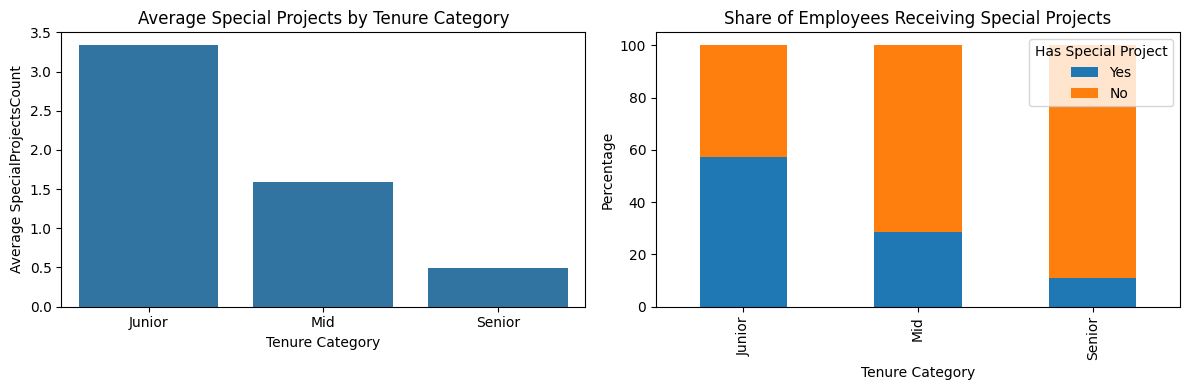

In [26]:
# create binary indicator for whether an employee has ever received a special project
df['HasSpecialProject'] = np.where(df['SpecialProjectsCount'] > 0, 'Yes', 'No')

# summary statistics by tenure category
special_project_summary = df.groupby('TenureCategory').agg(
    employee_count=('SpecialProjectsCount', 'size'),
    avg_special_projects=('SpecialProjectsCount', 'mean'),
    median_special_projects=('SpecialProjectsCount', 'median'),
    max_special_projects=('SpecialProjectsCount', 'max'),
    pct_with_special_project=('HasSpecialProject', lambda x: (x == 'Yes').mean() * 100)
).round(2)

display(special_project_summary)

# proportion table
special_project_prop = pd.crosstab(
    df['TenureCategory'],
    df['HasSpecialProject'],
    normalize='index'
).mul(100).round(2)

display(special_project_prop)

# visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# average special projects by tenure category
sns.barplot(
    data=df,
    x='TenureCategory',
    y='SpecialProjectsCount',
    estimator='mean',
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title('Average Special Projects by Tenure Category')
axes[0].set_xlabel('Tenure Category')
axes[0].set_ylabel('Average SpecialProjectsCount')

# percentage with and without special project
special_project_prop[['Yes', 'No']].plot(
    kind='bar',
    stacked=True,
    ax=axes[1]
)

axes[1].set_title('Share of Employees Receiving Special Projects')
axes[1].set_xlabel('Tenure Category')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Has Special Project')

plt.tight_layout()
plt.show()

Surprisingly enough, The result does not support the idea that senior employees are more likely to receive special projects. Instead, the pattern moves in the opposite direction, with junior employees showing the highest exposure.

Junior employees have the highest average number of special projects and the largest share of employees who have received at least one. This pattern then declines across mid and senior groups. The median values also strengthen this finding, since both mid and senior employees have a median of 0, while the junior group shows a much higher median.

This suggests that special projects in this dataset may be used more as part of early employee development rather than as assignments mainly given to longer-tenured employees. While this result is only descriptive, it shows that tenure alone does not appear to increase the chance of receiving special projects.

### **Numeric Features vs Target**

After understanding the overall numeric distributions, the next step is to connect them with `PerformanceScore` and see whether any clearer pattern begins to emerge.

In [27]:
# Average all numeric features on target
df.groupby('PerformanceScore').agg(
    avg_Salary = ('Salary', 'mean'),
    avg_EnggSurvey = ('EngagementSurvey', 'mean'),
    avg_EmpSatisf = ('EmpSatisfaction', 'mean'),
    avg_SpecialProj = ('SpecialProjectsCount', 'mean'),
    avg_tardiness = ('DaysLateLast30', 'mean'),
    avg_absentsm = ('Absences', 'mean'),
    avg_age = ('StartWorkAge', 'mean'),
    avg_tenure = ('Tenure', 'mean')
).round(2)


,avg_Salary,avg_EnggSurvey,avg_EmpSatisf,avg_SpecialProj,avg_tardiness,avg_absentsm,avg_age,avg_tenure
PerformanceScore,,,,,,,,
Exceeds,77144.86,4.48,4.11,1.11,0.00,10.49,34.46,5.22
Fully Meets,68366.72,4.24,3.95,1.32,0.02,10.22,33.67,4.93
Needs Improvement,68407.56,2.99,3.61,0.56,3.78,11.33,29.56,5.67
PIP,58971.08,2.22,2.54,0.54,4.31,8.31,33.62,4.85


The numeric comparison shows a much stronger story than the earlier datetime view.

The weaker performance groups, especially `Needs Improvement` and `PIP`, stand out through noticeably lower `EngagementSurvey` and `EmpSatisfaction` scores, much higher `DaysLateLast30`, lower average `Salary`, and fewer `SpecialProjectsCount`. For example, the average engagement score drops from **4.48** in `Exceeds` and **4.24** in `Fully Meets` to **2.99** in `Needs Improvement` and **2.22** in `PIP`. Lateness shows an even sharper gap, rising from almost zero in the stronger groups to around **3.8-4.3 days** in the lower-performing groups.

By contrast, `StartWorkAge` and `Tenure` remain relatively similar across classes. That means performance in this dataset seems less tied to employee background timing and more tied to day-to-day behavior, employee experience, and level of work exposure. This is an important shift, because it suggests the more useful modeling signals may come from how employees engage with work, not simply from who they are.

---

## **Categorical Features Exploration**

This stage explores the categorical variables thematically so the notebook can move beyond numeric averages and examine how performance patterns look across employee groups, employment outcomes, and organizational structure.

In [28]:
# query categorical data, except target data
cat_columns = df.drop(columns=['PerformanceScore']).select_dtypes('object').columns
cat_columns

Index(['Position', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino',
       'RaceDesc', 'TermReason', 'EmploymentStatus', 'Department',
       'ManagerName', 'RecruitmentSource', 'IsMarried', 'IsTerminated',
       'HasSpecialProject'],
      dtype='object')

There are **13 categorical features** remaining after excluding the target variable.

These variables need careful reading for two reasons.

First, some of them contain sensitive demographic information such as race and Hispanic/Latino background, which should be handled ethically and interpreted with extra restraint.

Second, some categories describe overlapping business context, such as marital condition, termination status, and termination reason, so the goal is to understand their analytical value without over-counting the same story in different forms.

### **1. Personal Profile**

#### **Gender Distribution**

Sex
F    176
M    135
Name: count, dtype: int64

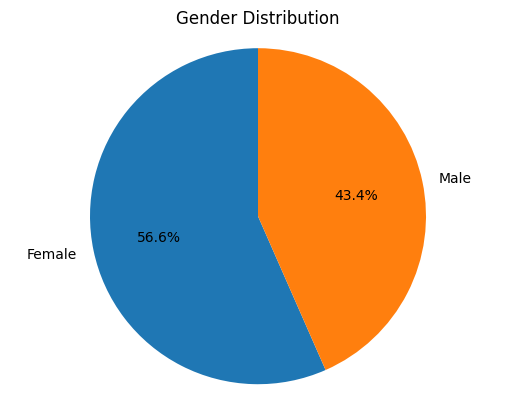

In [29]:
sex_counts = df['Sex'].value_counts()
display(sex_counts)

# visualize count
plt.figure()
plt.pie(
    sex_counts,
    labels=['Female', 'Male'],
    autopct='%1.1f%%',
    startangle=90)
plt.title('Gender Distribution')
plt.axis('equal')

plt.show()

The gender composition is slightly skewed toward female employees, with **56.6% female** and **43.4% male**.

At this stage, the chart only helps establish the overall makeup of the dataset. On its own, it does not show that gender is a meaningful performance driver, and it should not be treated as one without much stronger supporting evidence.

#### **Marital Status**

In [30]:
# Performance of Single vs Married Employee
marry = pd.crosstab(df['IsMarried'], df['PerformanceScore']).T
marry_prop = pd.crosstab(df['IsMarried'], df['PerformanceScore'], normalize=True).round(2).T

marry_combined = pd.concat(
    [marry.add_suffix(' (count)'), marry_prop.add_suffix('%')],
    axis=1
)
print('Performance of Single vs Married Employee:')
display(marry_combined)

# reason to be single
not_married = df[df['IsMarried'].isin(['No'])]

single_status = pd.crosstab(not_married['IsMarried'], df['MaritalDesc'])
print('\nReason for being single:')
display(single_status)

Performance of Single vs Married Employee:


IsMarried,No (count),Yes (count),No%,Yes%
PerformanceScore,,,,
Exceeds,26,11,0.08,0.04
Fully Meets,143,100,0.46,0.32
Needs Improvement,11,7,0.04,0.02
PIP,7,6,0.02,0.02



Reason for being single:


MaritalDesc,Divorced,Separated,Single,Widowed
IsMarried,,,,
No,30,12,137,8


The marital-status crosstab also shows only limited separation. Both married and non-married employees are still dominated by `Fully Meets`, and the proportions across the other performance categories remain fairly similar.

The non-married group is larger overall, which is why it contributes more employees to nearly every performance class. Looking deeper, most of that group is made up of employees whose `MaritalDesc` is `Single`, while the rest are split across divorced, separated, and widowed categories.

Taken together, marital status looks more useful as a background profile variable than as a strong explanatory factor for employee performance.

### **2. Sensitive Topic: Diversity Quota**

The next two variables, `RaceDesc` and `HispanicLatino`, need especially careful handling. They can help describe workforce diversity, but they **should not** be turned into direct decision criteria for employee evaluation.

Because of that, the purpose of this section is descriptive rather than investigative. The goal is to understand the makeup of the dataset and acknowledge any strong imbalance, not to claim that demographic identity causes performance differences.

#### **Race Distribution**

CitizenDesc,Eligible NonCitizen,Non-Citizen,US Citizen
RaceDesc,,,
American Indian or Alaska Native,0,0,3
Asian,3,0,26
Black or African American,5,3,72
Hispanic,0,0,1
Two or more races,1,0,10
White,3,1,183


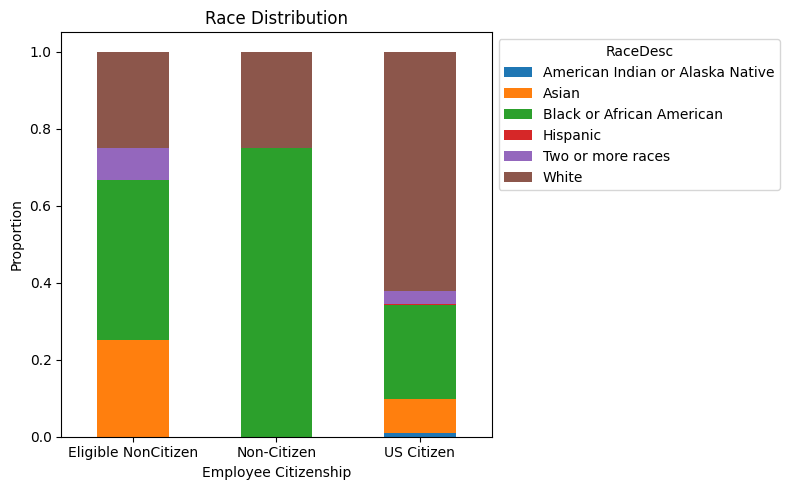

In [31]:
# Employee Race based on Citizenship
emp_race = pd.crosstab(df['CitizenDesc'], df['RaceDesc']).T
display(emp_race)

# visualize in proportion stacked on Citizenship 
emp_race = pd.crosstab(df['CitizenDesc'], df['RaceDesc'], normalize='index')
emp_race.plot(kind='bar', stacked=True, figsize=(8, 5))

plt.title('Race Distribution')
plt.ylabel('Proportion')
plt.xlabel('Employee Citizenship')
plt.xticks(rotation=360)
plt.legend(title='RaceDesc', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

The race distribution is heavily concentrated among **US citizens**, and within that group the largest category is `White`, followed by `Black or African American`, then `Asian`, while the non-citizen groups are much smaller.

This chart is useful for understanding dataset composition, but it **does not** provide a strong basis for predictive conclusions about performance.

#### **Are there any Latino?**

CitizenDesc,Eligible NonCitizen,Non-Citizen,US Citizen
HispanicLatino,,,
No,11,4,268
Yes,1,0,27


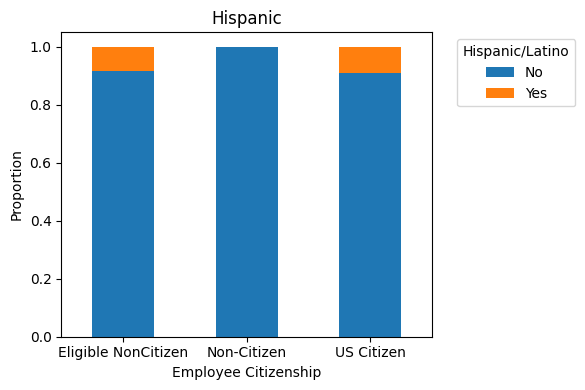

In [32]:
# Are there any Latino based on Citizenship?
ct_latino = pd.crosstab(df['CitizenDesc'], df['HispanicLatino']).T
display(ct_latino)

# visualize in proportion stacked on Citizenship 
ct_latino = pd.crosstab(df['CitizenDesc'], df['HispanicLatino'], normalize='index')
ct_latino.plot(kind='bar', stacked=True, figsize=(6, 4))

plt.title('Hispanic')
plt.ylabel('Proportion')
plt.xlabel('Employee Citizenship')
plt.xticks(rotation=360)
plt.legend(title='Hispanic/Latino', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The `HispanicLatino` field is even more sparse. Most employees are labelled `No`, while the `Yes` group is relatively small and appears almost entirely among US citizens.

With a minority group this small, the variable is more useful as a note on dataset representation than as an analytical lever. Any performance-based interpretation built on top of it would be too fragile and **ethically questionable** for practical HR use.

### **3. Active vs Terminated Employee Performance**

IsTerminated          No                  Yes                       
EmploymentStatus  Active Terminated for Cause Voluntarily Terminated
PerformanceScore                                                    
Exceeds               29                    1                      7
Fully Meets          162                    8                     73
Needs Improvement      8                    5                      5
PIP                    8                    2                      3

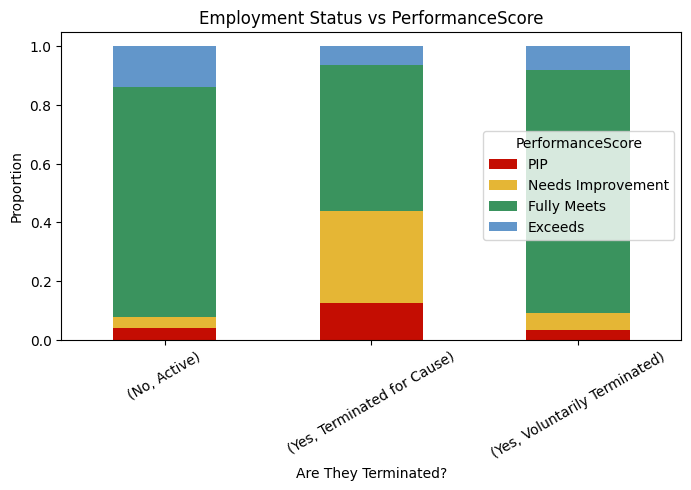

In [33]:
# EmploymentStatus vs Performance count
emp_status = pd.crosstab([df['IsTerminated'], df['EmploymentStatus']], df['PerformanceScore']).T
display(emp_status)

# visualize in proportion
emp_status = pd.crosstab([df['IsTerminated'], df['EmploymentStatus']], df['PerformanceScore'], normalize='index')

asc_order = ['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds']
colors=["#C40D02", "#E5B635", "#3A935E", "#6296CA"]

emp_status[asc_order].plot(kind='bar', stacked=True, figsize=(8, 4), color=colors)

plt.title('Employment Status vs PerformanceScore')
plt.ylabel('Proportion')
plt.xlabel('Are They Terminated?')
plt.xticks(rotation=30)
plt.show()

Employment status provides a more actionable view because it connects performance with real employee outcomes.

The stacked proportions show that active employees are still dominated by `Fully Meets`, which is expected in a functioning organization. Voluntarily terminated employees also remain mostly in `Fully Meets`, which suggests that leaving the company does not automatically mean weak performance. In contrast, the `Terminated for Cause` group contains a much heavier share of `Needs Improvement` and `PIP`.

This creates an important distinction: low performance appears more closely aligned with cause-based termination, while voluntary exit may reflect a different story such as opportunity, fit, reward, or personal choice.

In [34]:
# termination reason
terminated = df[df['EmploymentStatus'].isin(['Terminated for Cause', 'Voluntarily Terminated'])]

term_reason = pd.crosstab(terminated['TermReason'], terminated['EmploymentStatus'])
display(term_reason)

EmploymentStatus,Terminated for Cause,Voluntarily Terminated
TermReason,,
Another position,0,20
Fatal attraction,1,0
Learned that he is a gangster,1,0
attendance,6,1
career change,0,9
gross misconduct,1,0
hours,0,8
maternity leave - did not return,0,3
medical issues,0,3


The termination-reason breakdown supports that reading.

Voluntary exits are mainly associated with reasons such as `another position`, `unhappy`, `more money`, and `career change`. Such reason points more toward opportunity, dissatisfaction, or work-fit issues than formal performance failure.

On the other hand, cause-based termination is more concentrated around `attendance`, `performance`, and other disciplinary issues which aligns much more directly with weaker employee outcomes.

This pattern suggests that `EmploymentStatus` does not reflect a simple ordered progression, but rather different types of employment outcomes with different meanings.

Because of that, `EmploymentStatus` is treated as a nominal categorical feature and will be encoded using `One-Hot Encoding` in the modeling stage.

### **4. Departments that Meet Performance Expectations**

PerformanceScore                                   Exceeds  Fully Meets  \
Department           Position                                             
Admin Offices        Accountant I                        0            3   
                     Administrative Assistant            0            3   
                     Shared Services Manager             0            1   
                     Sr. Accountant                      0            2   
Executive Office     President & CEO                     0            1   
IT/IS                BI Developer                        0            4   
                     BI Director                         0            1   
                     CIO                                 1            0   
                     Data Analyst                        2            6   
                     Data Architect                      0            1   
                     Database Administrator              0            5   
                     Enterprise Architect                0            1   
                     IT Director                         1            0   
                     IT Manager - DB                     0            2   
                     IT Manager - Infra                  0            0   
                     IT Manager - Support                1            0   
                     IT Support                          1            7   
                     Network Engineer                    0            4   
                     Principal Data Architect            0            1   
                     Senior BI Developer                 0            3   
                     Sr. DBA                             0            2   
                     Sr. Network Engineer                0            5   
Production           Director of Operations              1            0   
                     Production Manager                  2           10   
                     Production Technician I            16          105   
                     Production Technician II            8           44   
Sales                Area Sales Manager                  2           21   
                     Director of Sales                   0            1   
                     Sales Manager                       0            2   
Software Engineering Software Engineer                   2            7   
                     Software Engineering Manager        0            1   

PerformanceScore                                   Needs Improvement  PIP  
Department           Position                                              
Admin Offices        Accountant I                                  0    0  
                     Administrative Assistant                      0    0  
                     Shared Services Manager                       0    0  
                     Sr. Accountant                                0    0  
Executive Office     President & CEO                               0    0  
IT/IS                BI Developer                                  0    0  
                     BI Director                                   0    0  
                     CIO                                           0    0  
                     Data Analyst                                  0    0  
                     Data Architect                                0    0  
                     Database Administrator                        0    0  
                     Enterprise Architect                          0    0  
                     IT Director                                   0    0  
                     IT Manager - DB                               0    0  
                     IT Manager - Infra                            1    0  
                     IT Manager - Support                          0    0  
                     IT Support                                    0    0  
                     Network Engineer                              0    1  
    

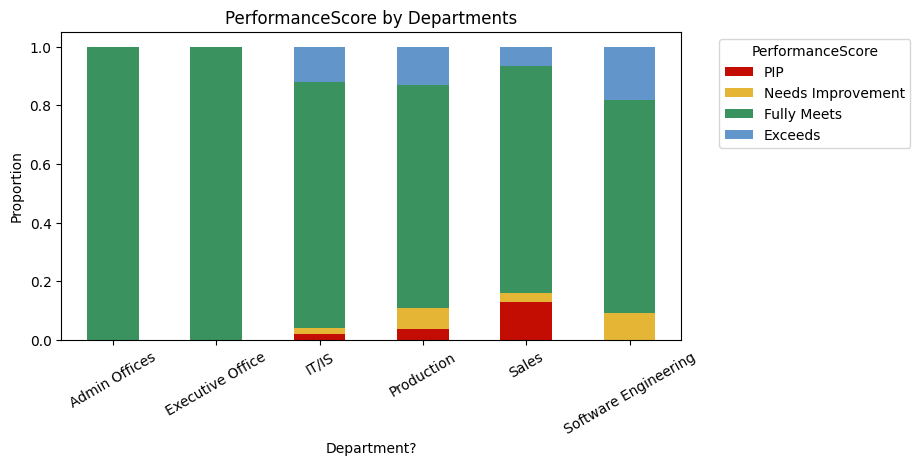

In [35]:
# EmploymentStatus vs Performance count
dept_performance = pd.crosstab([df['Department'], df['Position']], df['PerformanceScore'])
display(dept_performance)

# visualize in proportion
dept_performance = pd.crosstab(df['Department'], df['PerformanceScore'], normalize='index')

asc_order = ['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds']
colors=["#C40D02", "#E5B635", "#3A935E", "#6296CA"]

dept_performance[asc_order].plot(kind='bar', stacked=True, figsize=(8, 4), color=colors)

plt.title('PerformanceScore by Departments')
plt.ylabel('Proportion')
plt.xlabel('Department?')
plt.xticks(rotation=30)
plt.legend(title='PerformanceScore', bbox_to_anchor=(1.05, 1))
plt.show()

At the department level, `Fully Meets` remains the dominant class almost everywhere, which is consistent with the target imbalance already seen earlier. Even so, some differences still stand out.

`Sales` shows the highest visible share of `PIP`, while `Production` contains the largest absolute number of lower-performance employees simply because it is also the largest department. `IT/IS` and `Software Engineering` lean more strongly toward `Fully Meets` and `Exceeds`, although their sizes are much smaller than `Production`. `Admin Offices` and `Executive Office` appear very strong as well, but their employee counts are too small to generalize confidently.

This means department can be a useful screening lens, but it is still too broad to explain performance on its own. Position-level, manager-level, or work-condition context is still needed for deeper interpretation.

### **Question**: Can specific manager leadership influence employee performance?

Manager influence is a reasonable business question, because different managers can shape expectations, support, workload distribution, and team culture in different ways.

At the same time, manager-level interpretation needs caution. Some managers supervise large teams, while others handle only a few employees, and that difference can distort proportions very quickly. To keep the reading more grounded, the notebook checks the relationship in two ways: across all managers and again on a subset of managers with at least 10 employees.

In [36]:
target_order = ['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds']

manager_perf = pd.crosstab(df['ManagerName'], df['PerformanceScore'])[target_order]
manager_counts = manager_perf.sum(axis=1)

# proportions by manager
manager_perf_prop = manager_perf.div(manager_counts, axis=0).fillna(0).round(2)

# filter managers with enough data
min_employees = 10
manager_perf_large = manager_perf[manager_counts >= min_employees]

def cramers_v(chi2, n, r, k):
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

chi2_all, p_all, dof_all, _ = chi2_contingency(manager_perf)
chi2_large, p_large, dof_large, _ = chi2_contingency(manager_perf_large)

print('Overall manager vs PerformanceScore')
print(f'chi2 = {chi2_all:.2f}, p-value = {p_all:.4f}, Cramer V = {cramers_v(chi2_all, manager_perf.values.sum(), *manager_perf.shape):.3f}')
print()
print(f'Managers with >= {min_employees} employees')
print(f'chi2 = {chi2_large:.2f}, p-value = {p_large:.4f}, Cramer V = {cramers_v(chi2_large, manager_perf_large.values.sum(), *manager_perf_large.shape):.3f}')

Overall manager vs PerformanceScore
chi2 = 67.00, p-value = 0.2494, Cramer V = 0.268

Managers with >= 10 employees
chi2 = 48.79, p-value = 0.1354, Cramer V = 0.245


The chi-square results do not provide strong statistical evidence that `ManagerName` is associated with `PerformanceScore` in this dataset.

Across all managers, the relationship is not statistically significant (`p = 0.2494`), and the same conclusion remains when the analysis is limited to managers with at least 10 employees (`p = 0.1354`). The effect sizes are also only modest, which suggests that visible differences in the chart may be driven more by sample composition than by a clear manager-specific performance pattern.

In practical terms, that means manager identity should not be treated as a standalone explanation for employee performance based on this dataset alone.

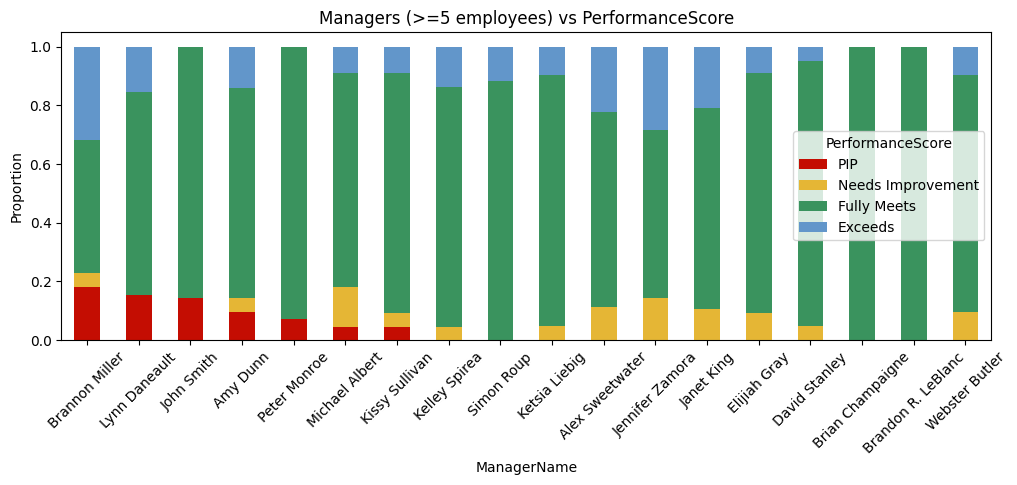

In [37]:
manager_count = df['ManagerName'].value_counts()
valid_managers = manager_count[manager_count >= 5].index  # valid if they manage >= 5 employees

manager = pd.crosstab(
    df[df['ManagerName'].isin(valid_managers)]['ManagerName'],
    df[df['ManagerName'].isin(valid_managers)]['PerformanceScore'],
    normalize='index'
)

manager = manager[asc_order].sort_values('PIP', ascending=False)

manager.plot(kind='bar', stacked=True, figsize=(12, 4), color=colors)
plt.title('Managers (>=5 employees) vs PerformanceScore')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.show()

The manager proportion chart reinforces the same point. Some managers appear to have a higher share of `PIP` or `Needs Improvement`, but many of these differences are based on relatively small team sizes, so a few employees can shift the pattern quickly.

A safer interpretation is that manager context may still matter, but it is too noisy here to serve as a direct ranking tool. For later modeling, this variable would need careful handling and should be used only if it improves prediction without encouraging misleading managerial conclusions.

---
# **Exploration Summary**
---

This exploration shows that employee performance in the dataset is not evenly distributed across all four categories. Most employees fall into `Fully Meets`, while the lower-performance groups are relatively small. That means the company is not facing a broad performance collapse, but it does contain a smaller subset of employees with noticeably weaker signals.

The clearest separators come from day-to-day work indicators and employee experience variables. Lower-performing employees tend to report lower engagement and satisfaction, earn less on average, participate in fewer special projects, and show much higher lateness. By contrast, `StartWorkAge`, `Tenure`, gender, and marital status provide much weaker separation.

Employment context also matters. Cause-based terminations contain a heavier share of `Needs Improvement` and `PIP`, while voluntary exits are still dominated by `Fully Meets`, which suggests that leaving the company and performing poorly are not the same issue. Department-level views also show some concentration of lower performance, especially in Sales and parts of Production, although broad department labels alone are still too coarse to explain everything.

Finally, the notebook draws an important boundary around interpretation. Sensitive demographic variables may describe who is represented in the dataset, but they should not become operational criteria for employee evaluation. For the next stage, the modeling work should focus more on behavioral, work-condition, and employee-experience variables, while also handling class imbalance carefully.

---
# **Up Next: Model Training**
---

The next stage continues in a separate notebook titled [employee-performance_modeling-prediction.ipynb](employee-performance_modeling-prediction.ipynb).

That notebook will focus on feature preparation for modeling, class imbalance handling, algorithm comparison, evaluation, and prediction-oriented interpretation built on top of the exploratory findings from this analysis.

In [38]:
# saving latest data for modeling
df.to_csv('dataset/HRDataset_v14_cleaned.csv', index=False)